# Exploration de la collection multicatégorielle

Ce notebook contrôle la collection Qdrant équilibrée utilisée pour l'expérimentation : 900 unités documentaires, réparties dans neuf catégories de 100 unités. Il affiche la distribution par catégorie et un exemple de recherche vectorielle.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))
from src.config import settings
from src.database import VectorStore
from src.embeddings import EmbeddingEncoder

COLLECTION_NAME = 'experiment_multicategory_900'
store = VectorStore(url=settings.qdrant_url, api_key=settings.qdrant_api_key, collection_name=COLLECTION_NAME)
encoder = EmbeddingEncoder('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')
print(f'Projet : {PROJECT_ROOT}')
print(f'Collection Qdrant : {COLLECTION_NAME}')

Projet : /Users/joelkouraogo/Desktop/Master 2 IBAM ISIE Soutenance 2026/Projet/projet_vectoriel
Collection Qdrant : experiment_multicategory_900


In [2]:
points, _ = store.client.scroll(collection_name=COLLECTION_NAME, limit=1000, with_payload=True, with_vectors=False)
documents = pd.DataFrame([point.payload for point in points])
distribution = (documents['category'].value_counts().sort_index().rename_axis('Catégorie').reset_index(name='Nombre de documents'))
print(f'Nombre total de documents : {len(documents)}')
distribution

Nombre total de documents : 900


,Catégorie,Nombre de documents
0,Actualités,100
1,Actualités internationales,100
2,Droit et réglementation,100
3,FQuADRetrieval,100
4,Mémoire académique,100
5,Santé et recherche biomédicale,100
6,Sciences et technologies,100
7,Sport,100
8,Économie et entreprises,100


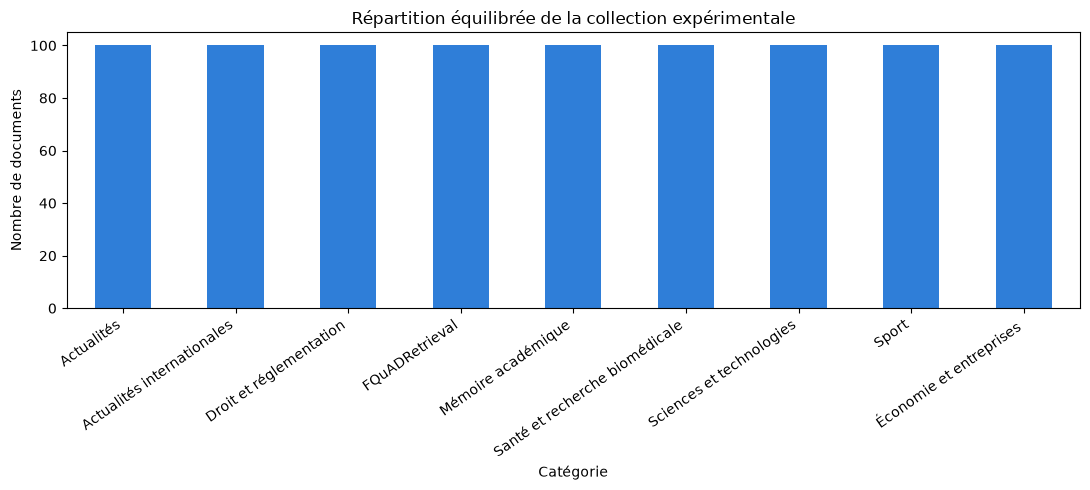

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Dimension des vecteurs : 384


In [3]:
ax = distribution.plot.bar(x='Catégorie', y='Nombre de documents', legend=False, color='#2f7ed8', figsize=(11, 5))
ax.set_title('Répartition équilibrée de la collection expérimentale')
ax.set_xlabel('Catégorie')
ax.set_ylabel('Nombre de documents')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()
print('Dimension des vecteurs :', encoder.dimension)

In [4]:
requete = 'Quels sont les bénéfices de la vaccination ?'
resultats = store.search(encoder.encode(requete), limit=5)
pd.DataFrame([
    {'rang': rang, 'score': round(resultat.score, 4), 'titre': resultat.payload.get('title'), 'catégorie': resultat.payload.get('category')}
    for rang, resultat in enumerate(resultats, start=1)
])

,rang,score,titre,catégorie
0,1,0.4804,lincoln/newsquadfr,Actualités
1,2,0.4804,lincoln/newsquadfr,Actualités
2,3,0.4804,lincoln/newsquadfr,Actualités
3,4,0.4804,lincoln/newsquadfr,Actualités
4,5,0.4804,lincoln/newsquadfr,Actualités


## Vérification de l'index Qdrant

La collection est déjà indexée. La distribution affichée ci-dessus confirme que chaque catégorie comporte 100 unités documentaires.

In [5]:
assert len(documents) == 900, 'La collection doit contenir 900 documents.'
assert distribution['Nombre de documents'].eq(100).all(), 'Chaque catégorie doit contenir 100 documents.'
print('Contrôle réussi : 900 documents répartis à parts égales dans 9 catégories.')

Contrôle réussi : 900 documents répartis à parts égales dans 9 catégories.


In [6]:
print('Exemple de requête :', requete)
for rang, resultat in enumerate(resultats, start=1):
    print(f"{rang}. [{resultat.payload.get('category')}] {resultat.payload.get('title')} — score {resultat.score:.4f}")

Exemple de requête : Quels sont les bénéfices de la vaccination ?
1. [Actualités] lincoln/newsquadfr — score 0.4804
2. [Actualités] lincoln/newsquadfr — score 0.4804
3. [Actualités] lincoln/newsquadfr — score 0.4804
4. [Actualités] lincoln/newsquadfr — score 0.4804
5. [Actualités] lincoln/newsquadfr — score 0.4804


## Suite

Modifiez la requête précédente pour contrôler qualitativement la pertinence sur les différentes catégories. Le notebook `evaluation.ipynb` mesure ensuite Recall@10, MRR@10 et le temps moyen de réponse sur 90 requêtes tests.